https://github.com/Trusted-AI/adversarial-robustness-toolbox/blob/main/examples/get_started_pytorch.py


Training model...
Epoch 1 loss: 0.2392
Epoch 2 loss: 0.0584
Epoch 3 loss: 0.0429
Clean accuracy: 98.84%
Adversarial accuracy (first batch): 39.70%


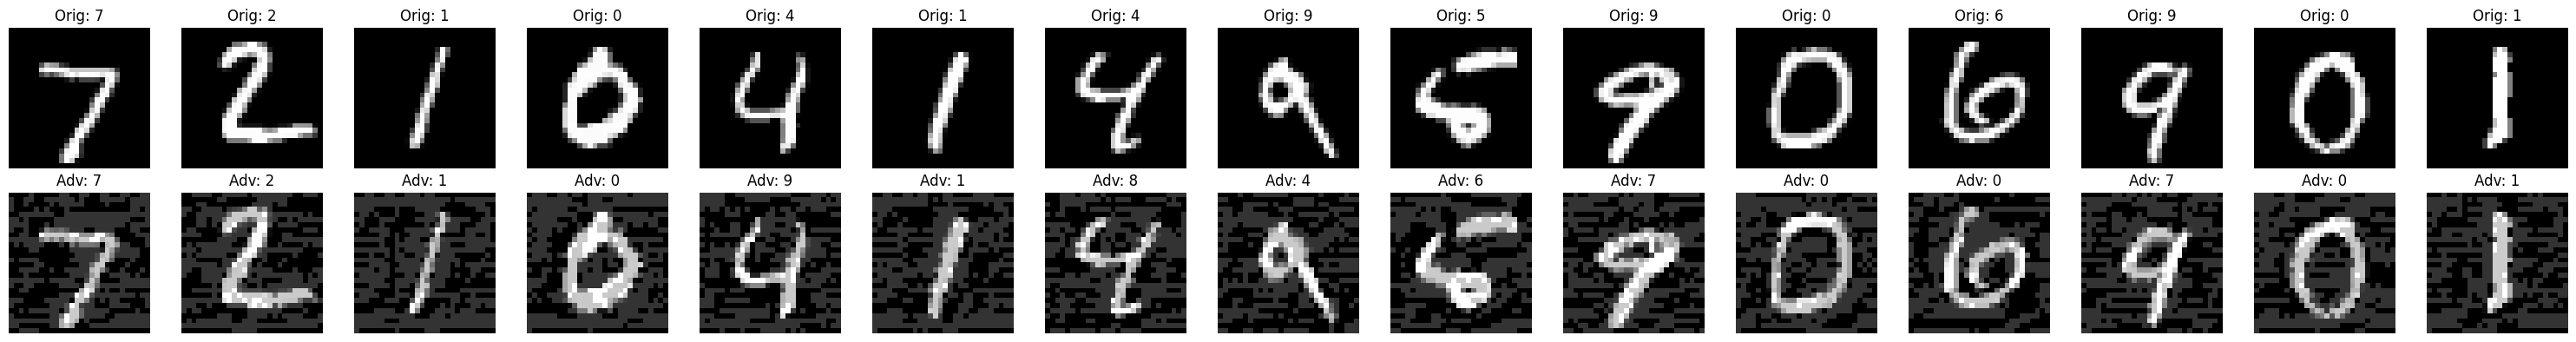

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import PyTorchClassifier

# 1. Prepare MNIST loaders
transform = transforms.Compose(
    [
        transforms.ToTensor(),  # scales to [0,1]
    ]
)
trainset = torchvision.datasets.MNIST(
    root="./data_gitignore", train=True, download=True, transform=transform
)
testset = torchvision.datasets.MNIST(
    root="./data_gitignore", train=False, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)


# 2. Define simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

# 3. Train model (few epochs for demo)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Training model...")
model.train()
for epoch in range(3):
    running_loss = 0.0
    for X, y in trainloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
    print(f"Epoch {epoch+1} loss: {running_loss/len(trainset):.4f}")

# 4. Wrap in ART PyTorchClassifier
# Note: classifier expects logits, so no softmax in model.
classifier = PyTorchClassifier(
    model=model,
    clip_values=(0.0, 1.0),
    loss=criterion,
    optimizer=optimizer,
    input_shape=(1, 28, 28),
    nb_classes=10,
    device_type="gpu" if torch.cuda.is_available() else "cpu",
)

# 5. Evaluate on clean test data
model.eval()
correct = 0
total = 0
for X, y in testloader:
    preds = classifier.predict(X.numpy())
    labels = np.argmax(preds, axis=1)
    correct += (labels == y.numpy()).sum()
    total += y.size(0)
print(f"Clean accuracy: {100*correct/total:.2f}%")

# 6. Create and run FGSM attack
attack = FastGradientMethod(estimator=classifier, eps=0.2)
x_test = next(iter(testloader))[0].numpy()  # take first batch
y_test = next(iter(testloader))[1].numpy()
x_test_adv = attack.generate(x=x_test)

# 7. Evaluate on adversarial examples
preds_adv = classifier.predict(x_test_adv)
acc_adv = np.mean(np.argmax(preds_adv, axis=1) == y_test)
print(f"Adversarial accuracy (first batch): {100*acc_adv:.2f}%")

# 8. Visualize some examples
n = 15  # number of pairs to show (so 2*n = 30 images)
plt.figure(figsize=(int(n*2), 4))
for i in range(n):
    # original
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"Orig: {y_test[i]}")
    plt.axis("off")

    # adversarial
    plt.subplot(2, n, n + i + 1)
    plt.imshow(x_test_adv[i].squeeze(), cmap="gray")
    plt.title(f"Adv: {np.argmax(preds_adv[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()
